# Demo 3: Feedforward Neural Networks for Regression
This notebook uses the **California Housing** dataset to show:
- FFNN for regression on a real-world problem
- comparison with Ridge Regression, Random Forest, and SVR
- hyperparameter tuning for MLPRegressor
- regression metrics and residual plots

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

print("Dataset shape:", X.shape)
X.head()

Dataset shape: (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

## Compare models

In [4]:
models = {
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=250, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "SVR (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=10, epsilon=0.1))
    ]),
    "FFNN Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(60, 30),
            activation="relu",
            solver="adam",
            alpha=0.0005,
            learning_rate_init=0.001,
            max_iter=500,
            early_stopping=True,
            random_state=RANDOM_STATE
        ))
    ])
}

rows = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    pred = model.predict(X_test)

    rows.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "MAE": mean_absolute_error(y_test, pred),
        "R^2": r2_score(y_test, pred)
    })

results = pd.DataFrame(rows).sort_values("RMSE")
results

,Model,RMSE,MAE,R^2
1,Random Forest,0.502407,0.327270,0.809244
3,FFNN Regressor,0.522664,0.358285,0.793550
2,SVR (RBF),0.565970,0.376230,0.757922
0,Ridge Regression,0.735593,0.529691,0.591075


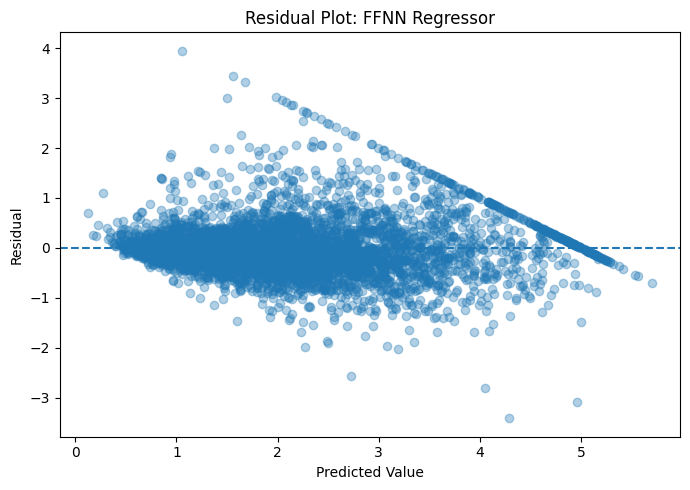

In [5]:
# Residual plot for the baseline FFNN regressor
ffnn_reg = fitted_models["FFNN Regressor"]
pred_ffnn = ffnn_reg.predict(X_test)
residuals = y_test - pred_ffnn

plt.figure(figsize=(7, 5))
plt.scatter(pred_ffnn, residuals, alpha=0.35)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Value")
plt.ylabel("Residual")
plt.title("Residual Plot: FFNN Regressor")
plt.tight_layout()
plt.show()

## Hyperparameter tuning for FFNN regression

In [6]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        solver="adam",
        activation="relu",
        max_iter=600,
        early_stopping=True,
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    "model__hidden_layer_sizes": [(40,), (80,), (60, 30), (100, 50)],
    "model__alpha": [0.0001, 0.001, 0.01],
    "model__learning_rate_init": [0.0005, 0.001, 0.005]
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)
print("Best CV RMSE:", round(-grid.best_score_, 4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'model__alpha': 0.01, 'model__hidden_layer_sizes': (100, 50), 'model__learning_rate_init': 0.005}
Best CV RMSE: 0.52


In [7]:
best_reg = grid.best_estimator_
pred_best = best_reg.predict(X_test)

print("Tuned FFNN test RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)), 4))
print("Tuned FFNN test MAE: ", round(mean_absolute_error(y_test, pred_best), 4))
print("Tuned FFNN test R^2: ", round(r2_score(y_test, pred_best), 4))

Tuned FFNN test RMSE: 0.5227
Tuned FFNN test MAE:  0.3477
Tuned FFNN test R^2:  0.8012


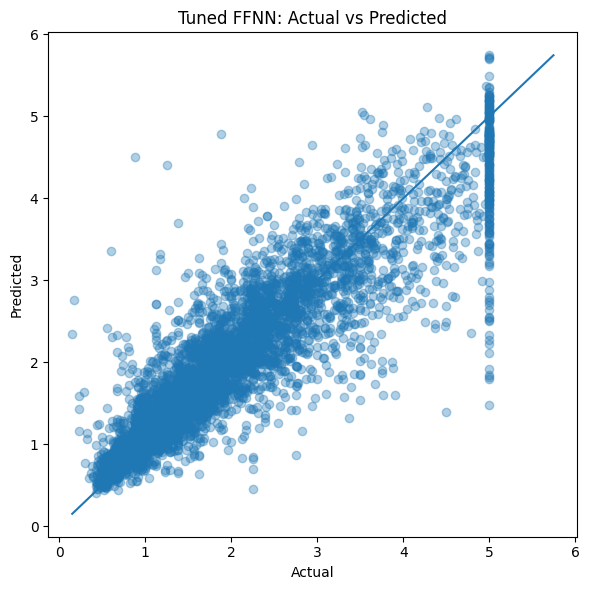

In [8]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_best, alpha=0.35)
lims = [min(y_test.min(), pred_best.min()), max(y_test.max(), pred_best.max())]
plt.plot(lims, lims)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Tuned FFNN: Actual vs Predicted")
plt.tight_layout()
plt.show()

#### What does the residual plot suggest?